# SALT3 — Staged WSD Continued-Pretraining (resumable · windowed · milestone-capturing)

One config-driven, single-arm CPT harness. Build a **ceiling** tokenized cache **once**, then:

- **Run a bounded session** (`SESSION_DOCS`). Re-run cell *4* to **continue** to the NEXT disjoint
  data window (never re-reads doc 0) or to **resume** the same window after a crash.
- **WSD learning rate** (warmup → flat `PEAK_LR` → cooldown only on milestone branches) keyed on the
  GLOBAL step, so a resumed/continued session **never re-warms**.
- **Milestones (hybrid):** a reloadable *stable* snapshot at every `MILESTONES_DOCS`; a short
  cosine→0 *cooldown branch* (on a reserved data pool) at each `TABLE_MILESTONES`.
- **Continuous metrics** (`metrics.jsonl`) plottable at any budget; **fixed cheap eval** (1024 chunks).

All logic lives in `salt3_staged_cpt*.py` / `salt3_staged_schedule.py`; this notebook is orchestration only.
Workflow: **build once → run session → re-run to continue → eval milestones**.

In [1]:
# HF auth (only needed to stream CulturaX for the ceiling build)
from huggingface_hub import login
try:
    from google.colab import userdata
    login(token=userdata.get('HF_TOKEN'))
except Exception:
    import os
    if os.environ.get('HF_TOKEN'):
        login(token=os.environ['HF_TOKEN'])

In [2]:
%%capture
!pip install -U "huggingface_hub>=1.13.0" transformers accelerate datasets safetensors sentencepiece tokenizers pandas matplotlib tqdm
# NO xformers on purpose: NeoBERT's fused xformers SwiGLU NaNs on some torch/CUDA builds; the
# artifacts are patched (salt3_common) to a pure-torch SwiGLU. Removing a stale wheel guarantees it:
!pip uninstall -y xformers

In [3]:
import sys, importlib
from pathlib import Path
import torch

try:
    from google.colab import drive; drive.mount('/content/drive')
except Exception as e:
    print('Drive mount skipped:', e)

PROJECT_ROOT = Path('/content/drive/MyDrive/SALT3') if Path('/content/drive/MyDrive').exists() else Path.cwd() / 'SALT3'
sys.path.insert(0, str(PROJECT_ROOT / 'code')); sys.path.insert(0, '/content')

import salt3_common as sc; importlib.reload(sc)
import salt3_staged_schedule as sched; importlib.reload(sched)
import salt3_staged_cpt_manifest as mf; importlib.reload(mf)
import salt3_staged_cpt_callbacks as cbs; importlib.reload(cbs)
import salt3_staged_cpt_plot as scp; importlib.reload(scp)
import salt3_staged_cpt as scpt; importlib.reload(scpt)
from salt3_common import configure_environment, set_seed, ensure_dir

configure_environment(); set_seed(42)
INIT_ROOT     = PROJECT_ROOT / 'init'
RUNS_ROOT     = ensure_dir(PROJECT_ROOT / 'runs' / 'wsd')
DATASET_CACHE = ensure_dir(PROJECT_ROOT / 'datasets')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
import transformers
print('torch', torch.__version__, '| transformers', transformers.__version__, '| device', DEVICE)

Mounted at /content/drive
torch 2.11.0+cu128 | transformers 5.12.1 | device cuda


## 1. Configure  — edit one arm + budgets here; everything else is derived

In [4]:
INIT_NAME          = 'trung_salt_decpertoken_freezealigned'   # swap for a new init arm (one arm per run)
CEILING_DOCS       = 5_000_000                   # build the cache ONCE at this many docs (the max budget)
SESSION_DOCS       = 1_000_000                   # docs to train THIS session; re-run cell 4 to continue

MILESTONES_DOCS    = [100_000, 500_000, 1_000_000, 2_000_000, 3_000_000, 4_000_000]  # stable snapshot at each
TABLE_MILESTONES   = [1_000_000, 2_000_000, 3_000_000, 4_000_000]                    # + cooldown branch at each (thesis-table budgets)

MAX_SEQ_LEN        = 1024
EVAL_CHUNKS        = 1024     # fixed cheap in-loop eval (constant cost at any budget)
REPORT_EVAL_CHUNKS = 8192     # larger eval for the milestone report table
PEAK_LR            = 1e-4
PER_DEVICE_BS      = 32
GRAD_ACCUM         = 16       # effective batch 512 chunks/step
SEED               = 42
EVAL_RATIO         = 0.02
MLM_PROB           = 0.20
POOL_LEN_CHUNKS    = 20_000   # reserved cooldown pool (tail of the train split; disjoint from trunk)
WARMUP_STEPS       = None     # None -> auto compute_warmup_steps(planned trunk steps), pinned in the manifest

## 2. Tokenizer fingerprint — prove one ceiling cache is valid for every arm

In [5]:
from transformers import AutoTokenizer
from salt3_common import assert_shared_tokenizer

assert (INIT_ROOT / INIT_NAME / 'model' / 'model.safetensors').exists(), \
    f'{INIT_NAME} not found under {INIT_ROOT} — check INIT_NAME'
arms = sorted(p.name for p in INIT_ROOT.glob('trung_*') if (p / 'model' / 'model.safetensors').exists())
print(f'{len(arms)} arm(s):', arms)
if len(arms) > 1:
    toks = [AutoTokenizer.from_pretrained(INIT_ROOT / a / 'model', trust_remote_code=True) for a in arms]
    print('shared tokenizer fingerprint:', assert_shared_tokenizer(toks), '-> one ceiling cache valid for all arms')
else:
    print('single arm -> fingerprint assert skipped (nothing to compare)')

9 arm(s): ['trung_naive_random_zerobias', 'trung_random_meannorm', 'trung_salt_decpertoken', 'trung_salt_decpertoken_freezealigned', 'trung_salt_decscale05', 'trung_salt_decscale10', 'trung_salt_dectied', 'trung_salt_freezealigned', 'trung_salt_globalmap_freqbias']
shared tokenizer fingerprint: 3487ef147c62 -> one ceiling cache valid for all arms


## 3. Build the ceiling cache (once) — slow first time, instant cache-hit after

In [6]:
from transformers import AutoTokenizer
from salt3_common import make_mlm_datasets, read_cache_meta, chunks_to_steps

tok = AutoTokenizer.from_pretrained(INIT_ROOT / INIT_NAME / 'model', trust_remote_code=True)
# Builds (and caches) the FULL ceiling at CEILING_DOCS; the [0,1) slice returned here is discarded.
# GPU-free (pure stream+tokenize+pack) — fine to run on a cheap L4/CPU runtime, then train on A100.
make_mlm_datasets(tokenizer=tok, cache_dir=DATASET_CACHE, num_examples=CEILING_DOCS,
                  max_seq_len=MAX_SEQ_LEN, eval_ratio=EVAL_RATIO, seed=SEED,
                  chunk_start=0, chunk_end=1, eval_chunks=EVAL_CHUNKS)

meta = read_cache_meta(DATASET_CACHE, tok, CEILING_DOCS, MAX_SEQ_LEN, EVAL_RATIO, SEED)
ratio, eff_batch = meta['ratio_chunks_per_doc'], PER_DEVICE_BS * GRAD_ACCUM
pool = min(POOL_LEN_CHUNKS, max(1, meta['train_chunks'] // 5)) if TABLE_MILESTONES else 0
trunk_ceiling = meta['train_chunks'] - pool
print(f"ratio {ratio:.3f} chunks/doc | train {meta['train_chunks']:,} chunks | reserved pool {pool:,} | "
      f"trunk ceiling {trunk_ceiling:,} chunks (~{int(trunk_ceiling / ratio):,} trunk docs trainable)")
print(f"planned trunk steps ~= {chunks_to_steps(trunk_ceiling, eff_batch):,} | "
      f"est cache size ~= {meta['total_chunks'] * MAX_SEQ_LEN * 4 / 1e9:.1f} GB (int32, ~4 B/token)")

Tokenizer fingerprint: 3487ef147c62 (DebertaV2Tokenizer, vocab=30522)
Dataset cache key    : culturax_vi_5000000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit
Loading cached dataset from /content/drive/MyDrive/SALT3/datasets/culturax_vi_5000000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit ...


Loading dataset from disk:   0%|          | 0/39 [00:00<?, ?it/s]

  Window chunks [0, 1) -> 1 train + 1,024 eval chunks
ratio 0.954 chunks/doc | train 4,674,425 chunks | reserved pool 20,000 | trunk ceiling 4,654,425 chunks (~4,880,599 trunk docs trainable)
planned trunk steps ~= 9,091 | est cache size ~= 19.5 GB (int32, ~4 B/token)


## 4. Run a session — **re-run this cell to continue (next window) or resume (after a crash)**

In [7]:
res = scpt.run_session(
    init_name=INIT_NAME, session_docs=SESSION_DOCS,
    runs_root=RUNS_ROOT, init_root=INIT_ROOT, dataset_cache=DATASET_CACHE, ceiling_docs=CEILING_DOCS,
    max_seq_len=MAX_SEQ_LEN, peak_lr=PEAK_LR, warmup_steps=WARMUP_STEPS,
    milestones_docs=MILESTONES_DOCS, table_milestones=TABLE_MILESTONES, eval_chunks=EVAL_CHUNKS,
    per_device_bs=PER_DEVICE_BS, grad_accum=GRAD_ACCUM, seed=SEED, eval_ratio=EVAL_RATIO,
    mlm_probability=MLM_PROB, pool_len_chunks=POOL_LEN_CHUNKS, device=DEVICE)
print('status:', res['status'], '| window:', res.get('window'))
res.get('manifest')

[trung_salt_decpertoken_freezealigned] window chunks [1,907,316, 2,860,974) ~ 1,863 steps | global offset 3,726 | warmup 182
Tokenizer fingerprint: 3487ef147c62 (DebertaV2Tokenizer, vocab=30522)
Dataset cache key    : culturax_vi_5000000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit
Loading cached dataset from /content/drive/MyDrive/SALT3/datasets/culturax_vi_5000000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit ...


Loading dataset from disk:   0%|          | 0/39 [00:00<?, ?it/s]

  Window chunks [1,907,316, 2,860,974) -> 953,658 train + 1,024 eval chunks
  ✓ load_model_safe: all 172 keys loaded successfully


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Resume mode selected, but no trainer checkpoint exists yet; starting this run from its configured base model.


...

Step,Training Loss
25,1.247482
50,1.228905
75,1.220361
100,1.213196
125,1.203905
150,1.190584
175,1.183300
200,1.171828
225,1.163802
250,1.163587


Training Loss,Validation Loss,Step
1.105015,1.244748,559


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  cooldown branch -> /content/drive/MyDrive/SALT3/runs/wsd/trung_salt_decpertoken_freezealigned/milestone_3000000_cooled (final_lr=1.00e-04, eval_loss=1.2447479963302612)
[trung_salt_decpertoken_freezealigned] done: global_step=5,589 chunks=2,860,974 snapped=[100000, 500000, 1000000, 2000000, 3000000] cooled=[1000000, 2000000, 3000000]
status: trained | window: (1907316, 2860974)


{'init_name': 'trung_salt_decpertoken_freezealigned',
 'init_fp': '3487ef147c62',
 'global_step': 5589,
 'chunks_consumed': 2860974,
 'docs_consumed': 2999998,
 'tokens_seen': 2929637376,
 'milestones_snapped': [100000, 500000, 1000000, 2000000, 3000000],
 'milestones_cooled': [1000000, 2000000, 3000000],
 'wsd': {'peak_lr': 0.0001, 'warmup_steps': 182},
 'sessions': [{'ts': '2026-06-19 07:58:06',
   'window': [0, 953658],
   'steps': 1863,
   'global_step': 1863},
  {'ts': '2026-06-19 18:58:17',
   'window': [953658, 1907316],
   'steps': 1863,
   'global_step': 3726},
  {'ts': '2026-06-21 00:42:37',
   'window': [1907316, 2860974],
   'steps': 1863,
   'global_step': 5589}]}

## 5. Plot training curves by budget — slice with `max_docs` to any earlier budget

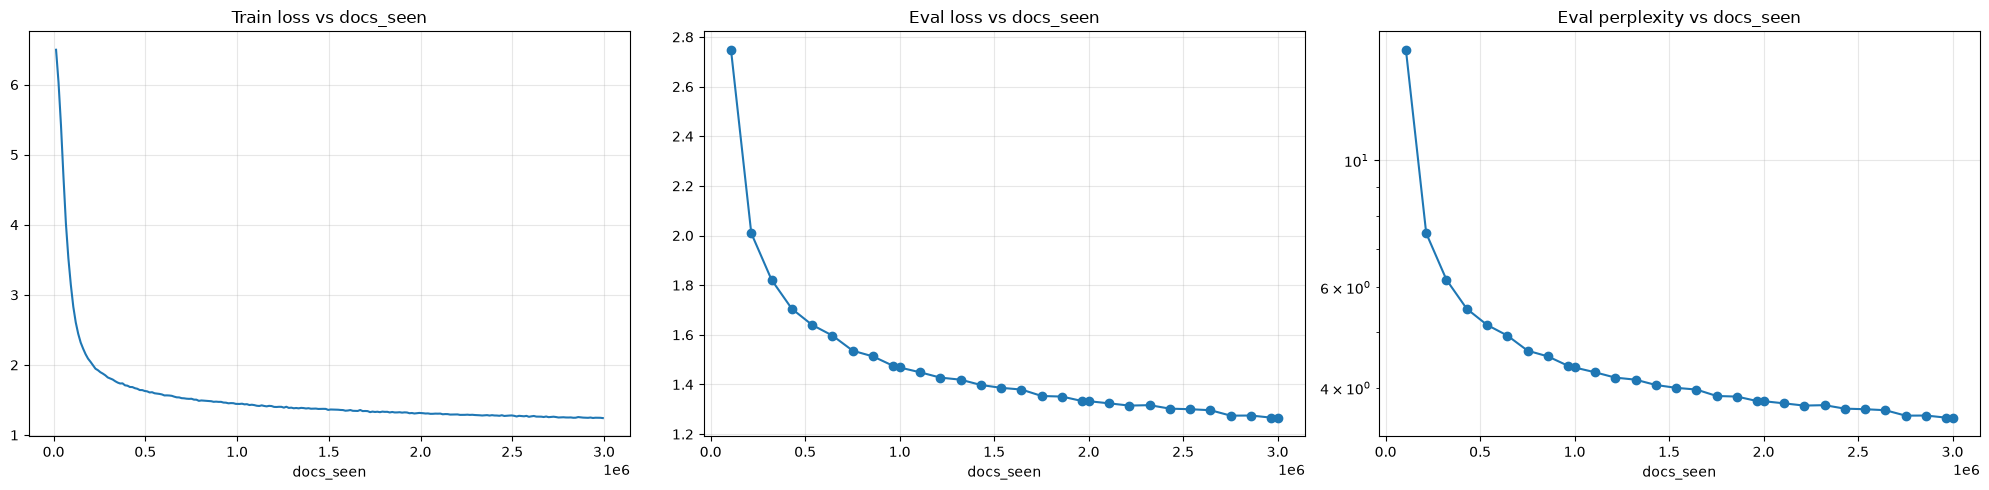

In [8]:
scpt.plot_by_budget(RUNS_ROOT / INIT_NAME / 'metrics.jsonl', x='docs_seen', max_docs=None)

## 6. Milestone eval — report PPL at each milestone (cooled preferred, else stable)

In [9]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForMaskedLM
from salt3_common import (load_model_safe, make_mlm_collator, make_mlm_datasets,
                          make_neo_mlm_trainer_class, training_args, eval_with_perplexity, write_json)

tok = AutoTokenizer.from_pretrained(INIT_ROOT / INIT_NAME / 'model', trust_remote_code=True)
_, report_eval = make_mlm_datasets(tokenizer=tok, cache_dir=DATASET_CACHE, num_examples=CEILING_DOCS,
                                   max_seq_len=MAX_SEQ_LEN, eval_ratio=EVAL_RATIO, seed=SEED,
                                   chunk_start=0, chunk_end=1, eval_chunks=REPORT_EVAL_CHUNKS)
collator = make_mlm_collator(tok, mlm_probability=MLM_PROB)
NeoMLMTrainer = make_neo_mlm_trainer_class()
arm_dir, rows = RUNS_ROOT / INIT_NAME, []
for m in MILESTONES_DOCS:
    cooled, stable = arm_dir / f'milestone_{m}_cooled', arm_dir / f'milestone_{m}_stable'
    mdir = cooled if (cooled / 'model.safetensors').exists() else (
        stable if (stable / 'model.safetensors').exists() else None)
    if mdir is None:
        print(f'  {m:>10,} docs: no snapshot yet'); continue
    model = load_model_safe(mdir, model_cls=AutoModelForMaskedLM, device=DEVICE)
    trainer = NeoMLMTrainer(model=model, args=training_args(arm_dir / '_eval_tmp', report_to='none'),
                            eval_dataset=report_eval, data_collator=collator, processing_class=tok)
    mt = eval_with_perplexity(trainer)
    rows.append({'milestone_docs': m, 'kind': mdir.name, 'eval_loss': mt['eval_loss'],
                 'perplexity': mt['eval_perplexity']})
    print(f"  {m:>10,} docs [{mdir.name}] eval_loss={mt['eval_loss']:.4f} ppl={mt['eval_perplexity']:.2f}")
    del model, trainer
write_json(arm_dir / 'milestone_eval.json', rows)
pd.DataFrame(rows)

Tokenizer fingerprint: 3487ef147c62 (DebertaV2Tokenizer, vocab=30522)
Dataset cache key    : culturax_vi_5000000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit
Loading cached dataset from /content/drive/MyDrive/SALT3/datasets/culturax_vi_5000000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit ...


Loading dataset from disk:   0%|          | 0/39 [00:00<?, ?it/s]

  Window chunks [0, 1) -> 1 train + 8,192 eval chunks
  ✓ load_model_safe: all 172 keys loaded successfully


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Loss,Validation Loss,Step
No log,2.846367,0


...

   2,000,000 docs [milestone_2000000_cooled] eval_loss=1.2843 ppl=3.61
  ✓ load_model_safe: all 172 keys loaded successfully


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Loss,Validation Loss,Step
No log,1.222155,0


   3,000,000 docs [milestone_3000000_cooled] eval_loss=1.2222 ppl=3.39
   4,000,000 docs: no snapshot yet


,milestone_docs,kind,eval_loss,perplexity
0,100000,milestone_100000_stable,2.846367,17.225095
1,500000,milestone_500000_stable,1.635124,5.130096
2,1000000,milestone_1000000_cooled,1.416876,4.124217
3,2000000,milestone_2000000_cooled,1.284265,3.612013
4,3000000,milestone_3000000_cooled,1.222155,3.394495


## (optional) CPU dry-run + smoke checks

Before the real GPU run, set `CEILING_DOCS=5_000`, `SESSION_DOCS=2_500`, `DEVICE='cpu'`,
`TABLE_MILESTONES=[]` and run cells 3→4 twice to watch the window advance. The cell below runs the
torch-free unit checks (WSD no-rewarm, manifest, windowing, eval-cap, fingerprint).

In [10]:
!python3 {PROJECT_ROOT / 'code' / 'salt3_staged_cpt_checks.py'}

staged-WSD-CPT CPU smoke checks
[A] no-undefined-names guard (cache-MISS build path)
  PASS  make_mlm_datasets: no undefined names
  PASS  _select_datasets: no undefined names
  PASS  _dataset_cache_dir: no undefined names
[A] WSD LR shape + no-rewarm
  PASS  ramp 0->peak over warmup
  PASS  flat == peak for all global >= warmup
  PASS  no re-warm: offset>=warmup -> local 0 is peak
  PASS  first session ramps: offset 0 -> local 1 < peak
[A] warmup clamp + cooldown
  PASS  warmup clamps to [20,500]
  PASS  warmup < dry-run total steps  (50 < 2500)
  PASS  cooldown cosine peak->0
  PASS  cooldown step cap respected
[A] manifest round-trip + idempotent advance
  PASS  round-trip equal
  PASS  two sessions: chunks doubled, global summed, 2 sessions
  PASS  mark_milestone idempotent
[A] chunk-window disjointness/continuity + constant eval
  Window chunks [0, 1,000) -> 1,000 train + 64 eval chunks
  Window chunks [1,000, 2,000) -> 1,000 train + 64 eval chunks
  PASS  windows contiguous
  PAS

In [11]:
from google.colab import runtime
runtime.unassign()